In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\DELL\Documents\HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [9]:
df.shape

(14999, 10)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [7]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [11]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [12]:
df['left'].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

<Axes: xlabel='salary'>

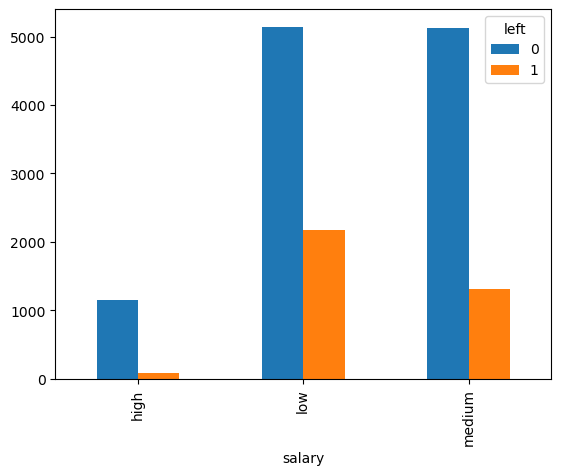

In [16]:
pd.crosstab(df.salary,df.left).plot(kind='bar')

<Axes: xlabel='Department'>

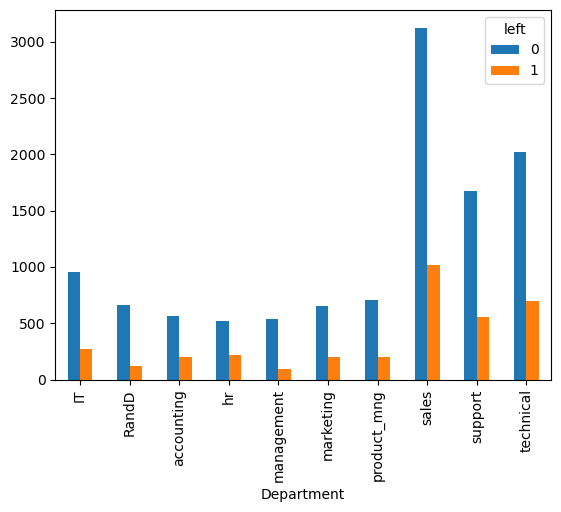

In [17]:
pd.crosstab(df.Department,df.left).plot(kind='bar')

In [15]:
subdf = df[['satisfaction_level','promotion_last_5years','average_montly_hours','salary']]
subdf.head()

,satisfaction_level,promotion_last_5years,average_montly_hours,salary
0,0.38,0,157,low
1,0.80,0,262,medium
2,0.11,0,272,medium
3,0.72,0,223,low
4,0.37,0,159,low


In [23]:
salary_dummies = pd.get_dummies(subdf.salary,prefix = 'salary').astype(int)
salary_dummies.head()

,salary_high,salary_low,salary_medium
0,0,1,0
1,0,0,1
2,0,0,1
3,0,1,0
4,0,1,0


In [27]:
df_with_dummies = pd.concat([subdf,salary_dummies],axis = 1)
df_with_dummies.head()

,satisfaction_level,promotion_last_5years,average_montly_hours,salary,salary_high,salary_low,salary_medium
0,0.38,0,157,low,0,1,0
1,0.80,0,262,medium,0,0,1
2,0.11,0,272,medium,0,0,1
3,0.72,0,223,low,0,1,0
4,0.37,0,159,low,0,1,0


In [28]:
df_with_dummies.drop('salary',axis = 'columns',inplace = True)
df_with_dummies.head()

,satisfaction_level,promotion_last_5years,average_montly_hours,salary_high,salary_low,salary_medium
0,0.38,0,157,0,1,0
1,0.80,0,262,0,0,1
2,0.11,0,272,0,0,1
3,0.72,0,223,0,1,0
4,0.37,0,159,0,1,0


In [29]:
X = df_with_dummies
X.head()

,satisfaction_level,promotion_last_5years,average_montly_hours,salary_high,salary_low,salary_medium
0,0.38,0,157,0,1,0
1,0.80,0,262,0,0,1
2,0.11,0,272,0,0,1
3,0.72,0,223,0,1,0
4,0.37,0,159,0,1,0


In [31]:
y = df.left
y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size = 0.3)

In [33]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [34]:
model.fit(X_train,y_train)

LogisticRegression()

In [35]:
model.predict(X_test)

array([0, 0, 0, ..., 1, 0, 0])